In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

In [2]:
df = pd.read_csv("restaurant_deliveries_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order Date          50000 non-null  object 
 1   Customer Latitude   50000 non-null  float64
 2   Customer Longitude  50000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 1.1+ MB


In [3]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Order Date          50000 non-null  datetime64[ns]
 1   Customer Latitude   50000 non-null  float64       
 2   Customer Longitude  50000 non-null  float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 1.1 MB


In [4]:
scaler = StandardScaler()
df[["Latitude_Scaled", "Longitude_Scaled"]] = scaler.fit_transform(df[["Customer Latitude", "Customer Longitude"]])
df.head()

,Order Date,Customer Latitude,Customer Longitude,Latitude_Scaled,Longitude_Scaled
0,2024-04-12,6.995278,79.795438,1.314191,-1.251001
1,2024-12-14,6.883918,79.859301,-0.829003,-0.033932
2,2024-09-27,6.848062,79.787815,-1.519070,-1.396282
3,2024-04-16,6.908621,79.941768,-0.353568,1.537662
4,2024-03-12,7.000688,79.855024,1.418312,-0.115444


In [5]:
def elbow_method(data, max_k):
    means = []
    inertias = []
    for k1 in range(1, max_k+1):
        kmeans_elbow = KMeans(n_clusters=k1)
        kmeans_elbow.fit(data)
        means.append(k1)
        inertias.append(kmeans_elbow.inertia_)
    
    plt.plot(means, inertias, 'o-')
    plt.title("Elbow Method")
    plt.xlabel("Number of Clusters")
    plt.ylabel("Intertia")
    plt.grid(True)
    plt.show()

c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  

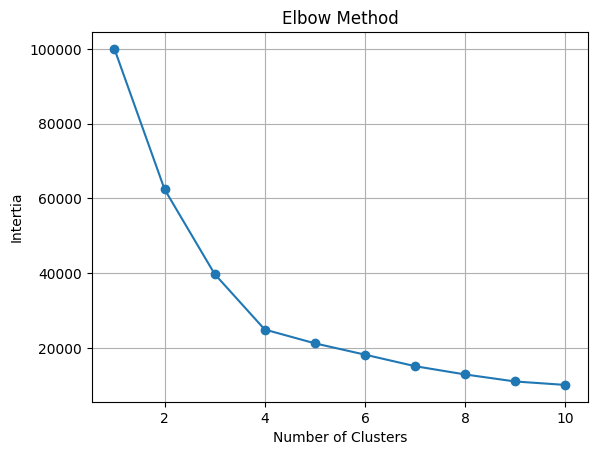

In [6]:
elbow_method(df[["Latitude_Scaled", "Longitude_Scaled"]], 10)

In [7]:
kmeans_optmial = KMeans(n_clusters=4)
kmeans_optmial.fit(df[["Latitude_Scaled", "Longitude_Scaled"]])
df["K-Means = 4"] = kmeans_optmial.labels_
df.head()

,Order Date,Customer Latitude,Customer Longitude,Latitude_Scaled,Longitude_Scaled,K-Means = 4
0,2024-04-12,6.995278,79.795438,1.314191,-1.251001,0
1,2024-12-14,6.883918,79.859301,-0.829003,-0.033932,3
2,2024-09-27,6.848062,79.787815,-1.519070,-1.396282,3
3,2024-04-16,6.908621,79.941768,-0.353568,1.537662,1
4,2024-03-12,7.000688,79.855024,1.418312,-0.115444,0


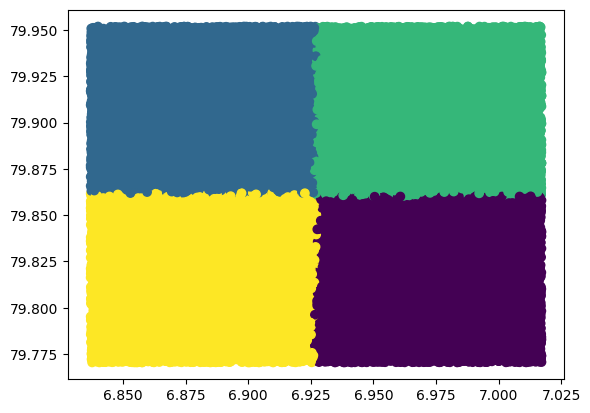

In [8]:
plt.scatter(x=df["Customer Latitude"], y=df["Customer Longitude"], c=df["K-Means = 4"])
plt.show()

In [9]:
df_cluster0 = df[df["K-Means = 4"] == 0]
df_cluster0.sort_values(by=["Order Date"], inplace=True)
df_grouped = df_cluster0.groupby(by="Order Date").size()
df_grouped = df_grouped.reset_index(name="Number of Orders")
data = df_grouped[["Number of Orders"]].to_numpy()
data_2 = data * 10

C:\Users\upeks\AppData\Local\Temp\ipykernel_5100\2160507699.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cluster0.sort_values(by=["Order Date"], inplace=True)


In [ ]:
data

In [ ]:
data_2

In [10]:
scaler2 = StandardScaler()
data_scaled = scaler2.fit_transform(data_2)

In [12]:
def create_sequences(data, sequence_length):
    sequences = []
    for i in range(len(data)-sequence_length):
        sequence = data[i:i+sequence_length]
        label = data[i+sequence_length]
        sequences.append((sequence, label))
    return sequences

In [14]:
sequences = create_sequences(data_scaled, 30)

In [ ]:
sequences

In [15]:
X = np.array([seq[0] for seq in sequences])
y = np.array([lbl[1] for lbl in sequences])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [18]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.lstm(x)
        output = out[:, -1, :]
        return output

In [19]:
model = LSTMModel(1, 32, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
epochs = 100

In [20]:
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([268, 1])) that is different to the input size (torch.Size([268, 32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/100], Loss: 0.9785
Epoch [20/100], Loss: 0.9774
Epoch [30/100], Loss: 0.9762
Epoch [40/100], Loss: 0.9689
Epoch [50/100], Loss: 0.9310
Epoch [60/100], Loss: 0.9061
Epoch [70/100], Loss: 0.8930
Epoch [80/100], Loss: 0.8874
Epoch [90/100], Loss: 0.8590
Epoch [100/100], Loss: 0.8707


In [21]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    test_loss = criterion(predictions, y_test)
    print(f"Test Loss: {test_loss.item():.4f}")

Test Loss: 0.8510


c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([68, 1])) that is different to the input size (torch.Size([68, 32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [22]:
predictions_org = scaler2.inverse_transform(predictions.numpy())
y_test_org = scaler2.inverse_transform(y_test.numpy())

In [ ]:
y_test_org

In [23]:
predictions_org_2 = predictions_org / 10
y_test_org_2 = y_test_org / 10 

In [ ]:
predictions_org_2

In [ ]:
plt.plot(predictions_org_2, label="Predicted Value")
plt.plot(y_test_org_2, label="Actual Values")
plt.legend()
plt.show()